In [2]:
import pandas as pd

In [3]:
import openpyxl

In [4]:
df_2 = pd.read_excel("online_retail_II.xlsx",sheet_name="Year 2009-2010")
df_1 = pd.read_excel("online_retail_II.xlsx",sheet_name="Year 2010-2011")

In [5]:
df_1.info()

<class 'pandas.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      541910 non-null  object        
 1   StockCode    541910 non-null  object        
 2   Description  540456 non-null  object        
 3   Quantity     541910 non-null  int64         
 4   InvoiceDate  541910 non-null  datetime64[us]
 5   Price        541910 non-null  float64       
 6   Customer ID  406830 non-null  float64       
 7   Country      541910 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [6]:
df = pd.concat((df_1,df_2),ignore_index=True)

In [7]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 65.1+ MB


In [9]:
df.shape

(1067371, 8)

In [10]:
list(df.columns)

['Invoice',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'Price',
 'Customer ID',
 'Country']

In [11]:
df = df.dropna(subset=["Customer ID"])

In [12]:
df.shape

(824364, 8)

In [13]:
df.info()

<class 'pandas.DataFrame'>
Index: 824364 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      824364 non-null  object        
 1   StockCode    824364 non-null  object        
 2   Description  824364 non-null  object        
 3   Quantity     824364 non-null  int64         
 4   InvoiceDate  824364 non-null  datetime64[us]
 5   Price        824364 non-null  float64       
 6   Customer ID  824364 non-null  float64       
 7   Country      824364 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 56.6+ MB


In [14]:
df = df[df["Quantity"]>0]

In [15]:
df = df[df["Price"]>0]

In [16]:
df = df[~df["Invoice"].astype(str).str.startswith("C")]

In [17]:
df["Revenue"] = df['Quantity']*df['Price']

In [18]:
df.info()

<class 'pandas.DataFrame'>
Index: 805549 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      805549 non-null  object        
 1   StockCode    805549 non-null  object        
 2   Description  805549 non-null  object        
 3   Quantity     805549 non-null  int64         
 4   InvoiceDate  805549 non-null  datetime64[us]
 5   Price        805549 non-null  float64       
 6   Customer ID  805549 non-null  float64       
 7   Country      805549 non-null  str           
 8   Revenue      805549 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(1), object(3), str(1)
memory usage: 61.5+ MB


In [19]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [20]:
df.info()

<class 'pandas.DataFrame'>
Index: 805549 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      805549 non-null  object        
 1   StockCode    805549 non-null  object        
 2   Description  805549 non-null  object        
 3   Quantity     805549 non-null  int64         
 4   InvoiceDate  805549 non-null  datetime64[us]
 5   Price        805549 non-null  float64       
 6   Customer ID  805549 non-null  float64       
 7   Country      805549 non-null  str           
 8   Revenue      805549 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(1), object(3), str(1)
memory usage: 61.5+ MB


In [21]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [22]:
df["Month"] = df['InvoiceDate'].dt.to_period("M").astype(str)

In [23]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12


In [24]:
df.info()

<class 'pandas.DataFrame'>
Index: 805549 entries, 0 to 1067370
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      805549 non-null  object        
 1   StockCode    805549 non-null  object        
 2   Description  805549 non-null  object        
 3   Quantity     805549 non-null  int64         
 4   InvoiceDate  805549 non-null  datetime64[us]
 5   Price        805549 non-null  float64       
 6   Customer ID  805549 non-null  float64       
 7   Country      805549 non-null  str           
 8   Revenue      805549 non-null  float64       
 9   Month        805549 non-null  str           
dtypes: datetime64[us](1), float64(3), int64(1), object(3), str(2)
memory usage: 67.6+ MB


In [25]:
import matplotlib.pyplot as plt

In [26]:
df.info

<bound method DataFrame.info of         Invoice StockCode                          Description  Quantity  \
0        536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1        536365     71053                  WHITE METAL LANTERN         6   
2        536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3        536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4        536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...         ...       ...                                  ...       ...   
1067366  538171     22271                 FELTCRAFT DOLL ROSIE         2   
1067367  538171     22750         FELTCRAFT PRINCESS LOLA DOLL         1   
1067368  538171     22751       FELTCRAFT PRINCESS OLIVIA DOLL         1   
1067369  538171     20970   PINK FLORAL FELTCRAFT SHOULDER BAG         2   
1067370  538171     21931               JUMBO STORAGE BAG SUKI         2   

                InvoiceDate  Price  Customer ID        

In [27]:
monthly_revnue = df.groupby("Month")["Revenue"].sum()

In [28]:
(monthly_revnue.head())

Month
2009-12    686654.160
2010-01    557319.062
2010-02    506371.066
2010-03    699608.991
2010-04    594609.192
Name: Revenue, dtype: float64

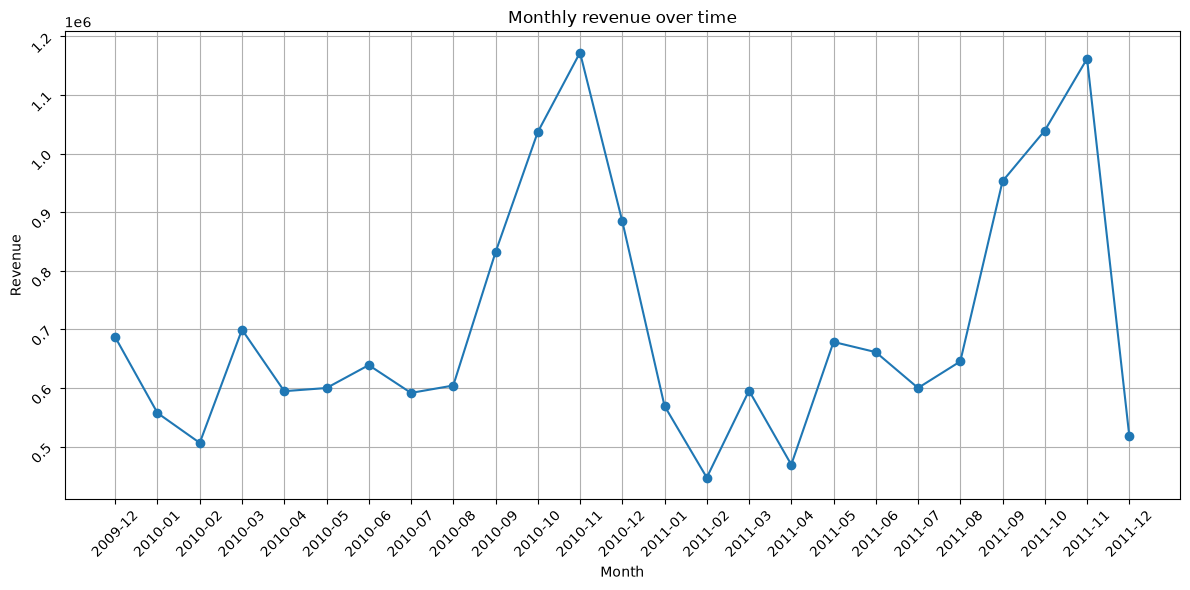

In [29]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_revnue.index,monthly_revnue.values,marker="o")
plt.title("Monthly revenue over time")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.show()

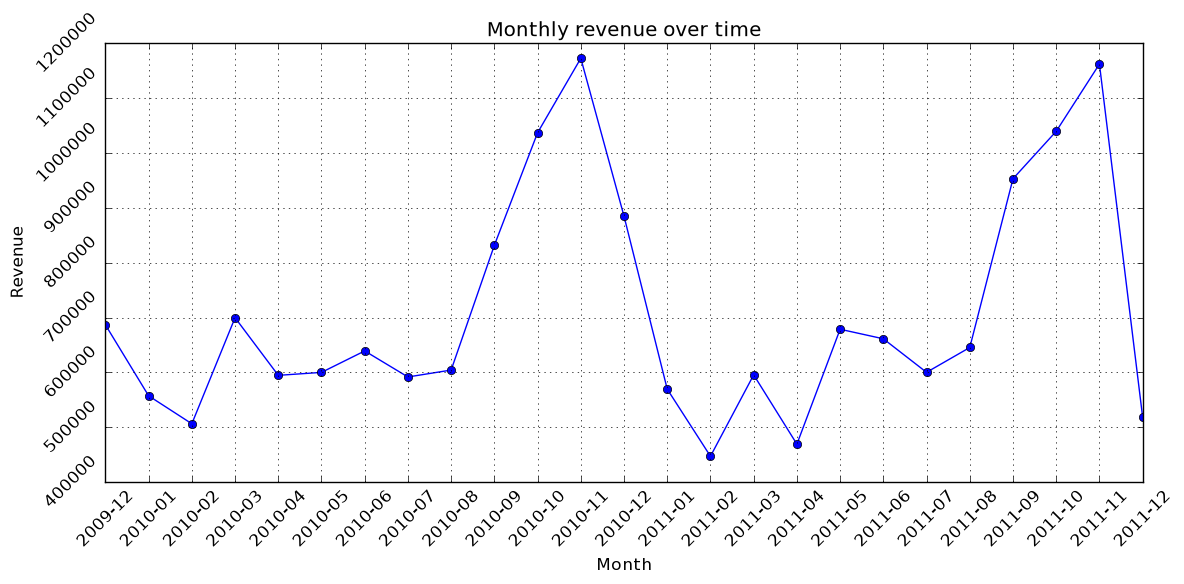

In [30]:
plt.figure(figsize=(12, 6))
plt.style.use('classic')
plt.plot(monthly_revnue.index,monthly_revnue.values,marker="o")
plt.title("Monthly revenue over time")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.show()

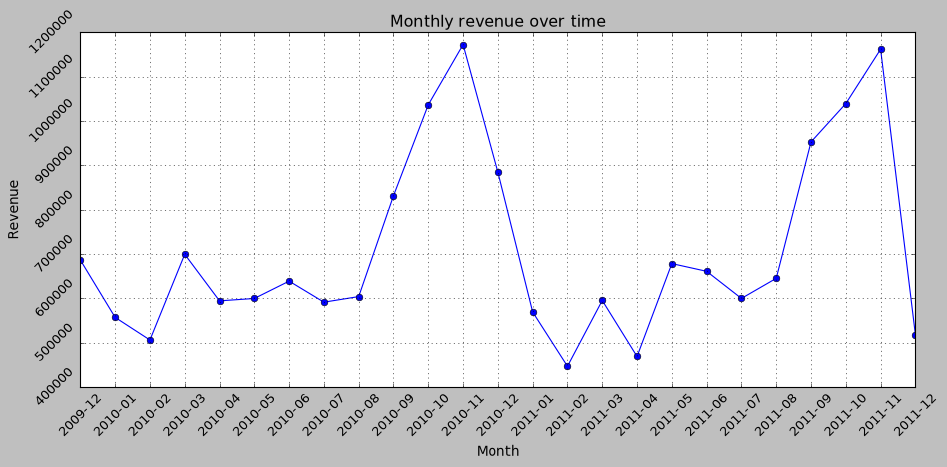

In [31]:
plt.figure(figsize=(12, 6))
plt.style.use('classic')
plt.plot(monthly_revnue.index,monthly_revnue.values,marker="o")
plt.title("Monthly revenue over time")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.show()

In [32]:
list((plt.style.available))

['Solarize_Light2',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'petroff6',
 'petroff8',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

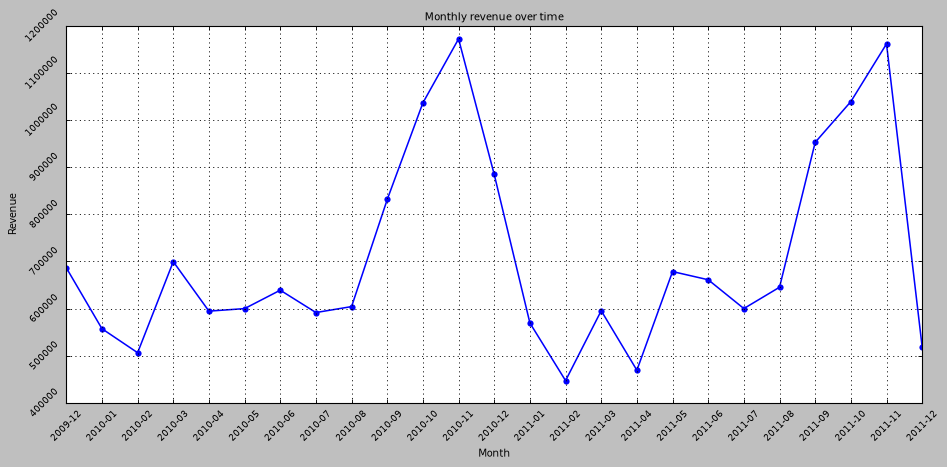

In [33]:
plt.figure(figsize=(12, 6))
plt.style.use('seaborn-v0_8-paper')
plt.plot(monthly_revnue.index,monthly_revnue.values,marker="o")
plt.title("Monthly revenue over time")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.show()

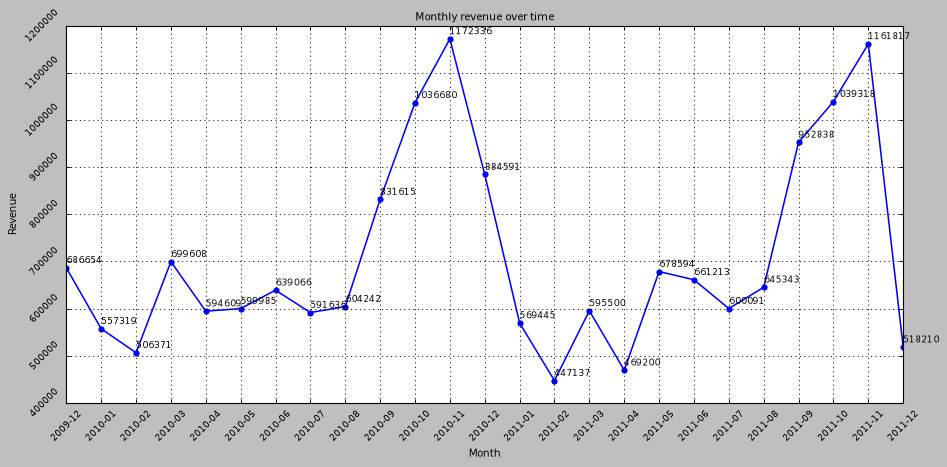

In [38]:
plt.figure(figsize=(12, 6))
plt.style.use('seaborn-v0_8-paper')
plt.plot(monthly_revnue.index,monthly_revnue.values,marker="o")
for index, value in enumerate(monthly_revnue):
    plt.text(monthly_revnue.index[index],value+10000,f'{int(value)}',ha="left",fontsize=8)
plt.title("Monthly revenue over time")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.show()

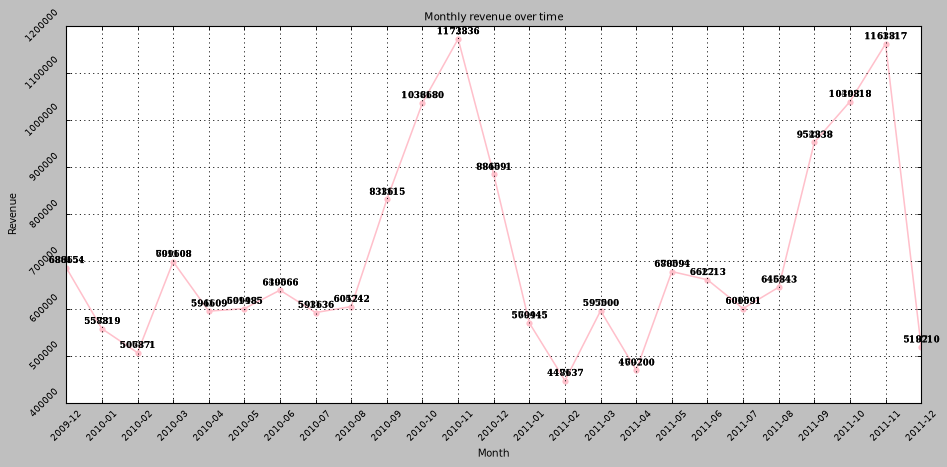

In [ ]:
font = {'family' : 'serif',
        'color':'black',
        'weight':'bold',
        'size':8}

plt.figure(figsize=(12, 6))

plt.style.use('seaborn-v0_8-paper')

plt.plot(monthly_revnue.index,monthly_revnue.values,marker="o",color = 'pink')
for x, y in enumerate(monthly_revnue):
    plt.text(monthly_revnue.index[x],y+10000,f'{int(y)}',ha="center",fontdict=font)
plt.title("Monthly revenue over time")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.show()

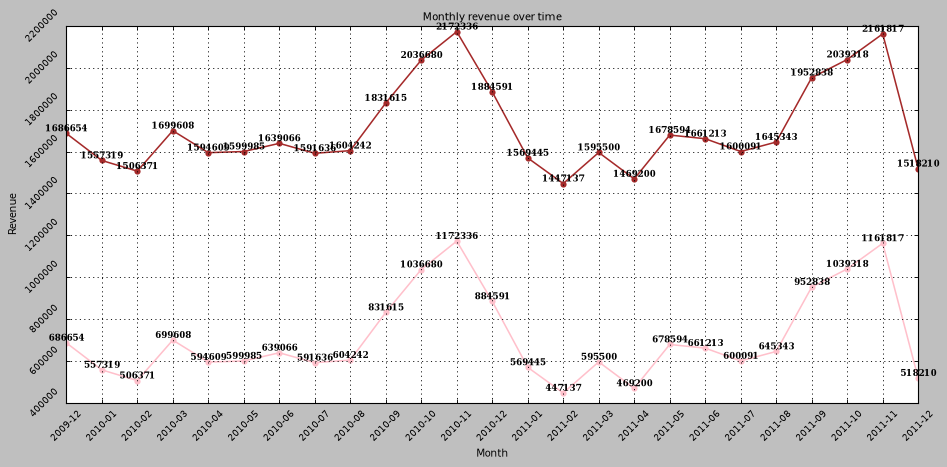

In [51]:
font = {'family' : 'serif',
        'color':'black',
        'weight':'bold',
        'size':8}

font_2 = {'family' : 'serif',
        'color':'black',
        'weight':'bold',
        'size':8}

plt.figure(figsize=(12, 6))

plt.style.use('seaborn-v0_8-paper')

plt.plot(monthly_revnue.index,monthly_revnue.values,marker="o",color = 'pink')

for x, y in enumerate(monthly_revnue):
    plt.text(monthly_revnue.index[x],y+10000,f'{int(y)}',ha="center",fontdict=font_2)

plt.plot(monthly_revnue.index,monthly_revnue.values+1000000,marker="o",color = 'brown')

for x, y in enumerate(monthly_revnue):
    plt.text(monthly_revnue.index[x],(y+1000000)+10000,f'{int(y+1000000)}',ha="center",fontdict=font)
plt.title("Monthly revenue over time")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.show()

In [52]:
revenue_by_country = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)

In [53]:
revenue_by_country

Country
United Kingdom    1.472315e+07
EIRE              6.216311e+05
Netherlands       5.542323e+05
Germany           4.312625e+05
France            3.552575e+05
Australia         1.699681e+05
Spain             1.091785e+05
Switzerland       1.003653e+05
Sweden            9.154972e+04
Denmark           6.986219e+04
Name: Revenue, dtype: float64

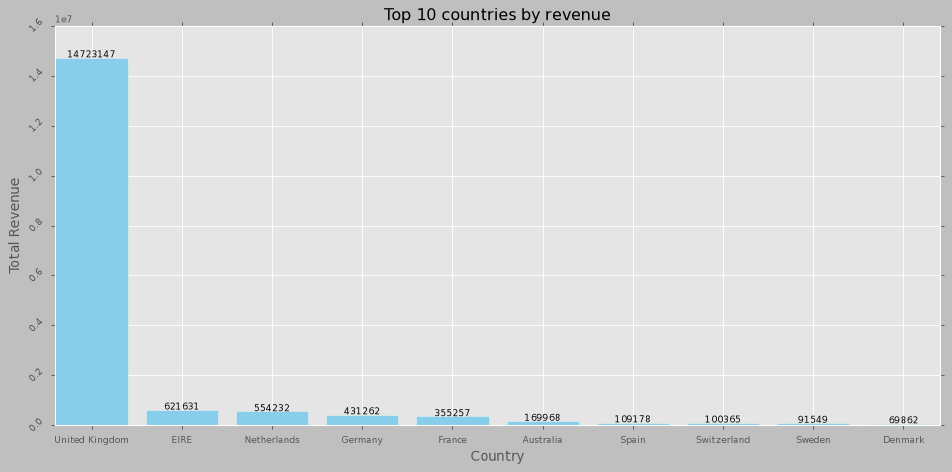

In [57]:
plt.figure(figsize=(12, 6))
plt.style.use('ggplot')
plt.bar(revenue_by_country.index,revenue_by_country.values,color = 'skyblue')
for index, value in enumerate(revenue_by_country):
    plt.text(revenue_by_country.index[index],value+10000,f'{int(value)}',ha="center",fontsize=8)
plt.title("Top 10 countries by revenue")
plt.xlabel("Country")
plt.ylabel("Total Revenue")
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()